In [1]:
from implicit_reps import *
import time
from differential import *
diffmod = DifferentialModule()

In [2]:
device='mps'

In [3]:
DEEPSDF_MODEL = load_deepsdf_model(ckpt_path = 'sdf_weights/surfaces/spike_best_epoch31.ckpt', device=device)

Loading deepsdf model onto  mps
DeepSDF Model loaded successfully on device: mps


In [4]:
DEEPSDF_MODEL = load_deepsdf_model(ckpt_path = 'sdf_weights/surfaces/spike_best_epoch31.ckpt', device=device)

pts = torch.rand(1,1000,3).to(device)
print('pts on', pts.device)
for i in range(5):
    start_time = time.time()
    result = DEEPSDF_MODEL(     { 'query_surface_points' :  pts }    )
    torch.mps.synchronize()
    end_time = time.time()
    print ('Time:', end_time - start_time)
    print('result on', result.device)



Loading deepsdf model onto  mps
DeepSDF Model loaded successfully on device: mps
pts on mps:0
Time: 0.1272749900817871
result on mps:0
Time: 0.01317596435546875
result on mps:0
Time: 0.011550188064575195
result on mps:0
Time: 0.010046958923339844
result on mps:0
Time: 0.00966334342956543
result on mps:0


In [5]:
DEEPSDF_MODEL = load_deepsdf_model(ckpt_path = 'sdf_weights/surfaces/spike_best_epoch31.ckpt', device=device)

pts = torch.rand(1,1000,3).to(device)
pts.requires_grad=True
print('pts on', pts.device)
for i in range(5):
    start_time = time.time()
    result = DEEPSDF_MODEL(     { 'query_surface_points' :  pts }    )

    gradient = diffmod.gradient(out=result, wrt = pts)
    torch.mps.synchronize()
    end_time = time.time()
    print ('Time:', end_time - start_time)
    print('result on', result.device)



Loading deepsdf model onto  mps
DeepSDF Model loaded successfully on device: mps
pts on mps:0
Time: 0.17952799797058105
result on mps:0
Time: 0.019228219985961914
result on mps:0
Time: 0.0118560791015625
result on mps:0
Time: 0.01186990737915039
result on mps:0
Time: 0.011636972427368164
result on mps:0


In [6]:
DEEPSDF_MODEL = load_deepsdf_model(ckpt_path = 'sdf_weights/surfaces/fruit_best.ckpt', device=device)

pts = torch.rand(100,10,3).to(device)
pts.requires_grad=True
print('pts on', pts.device)
for i in range(5):
    start_time = time.time()
    result = deepsdf(pts, model=DEEPSDF_MODEL)
    
    torch.mps.synchronize()
    end_time = time.time()
    print ('Fwd Time:', end_time - start_time)

    start_time = time.time()
    gradient = diffmod.gradient(out=result, wrt = pts)
    
    torch.mps.synchronize()
    end_time = time.time()
    print ('Backward Time:', end_time - start_time)
    
    



Loading deepsdf model onto  mps
DeepSDF Model loaded successfully on device: mps
pts on mps:0
Fwd Time: 0.45470523834228516
Backward Time: 0.08075213432312012
Fwd Time: 0.44573092460632324
Backward Time: 0.039022207260131836
Fwd Time: 0.4208540916442871
Backward Time: 0.0398411750793457
Fwd Time: 0.4443802833557129
Backward Time: 0.039443016052246094
Fwd Time: 0.42110300064086914
Backward Time: 0.03964114189147949


In [7]:
pts.shape

torch.Size([100, 10, 3])

Generating 100x100 slice through Z=0.0...


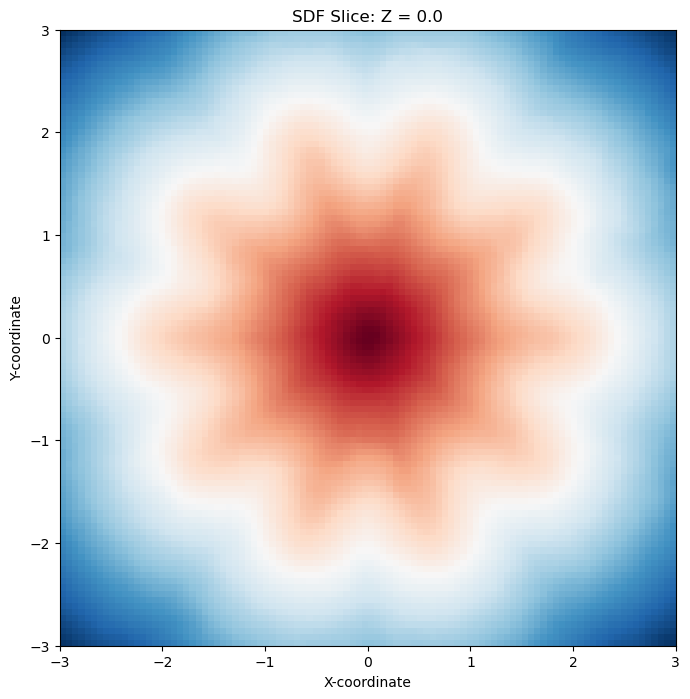

Generating 100x100 slice through Z=0.1...


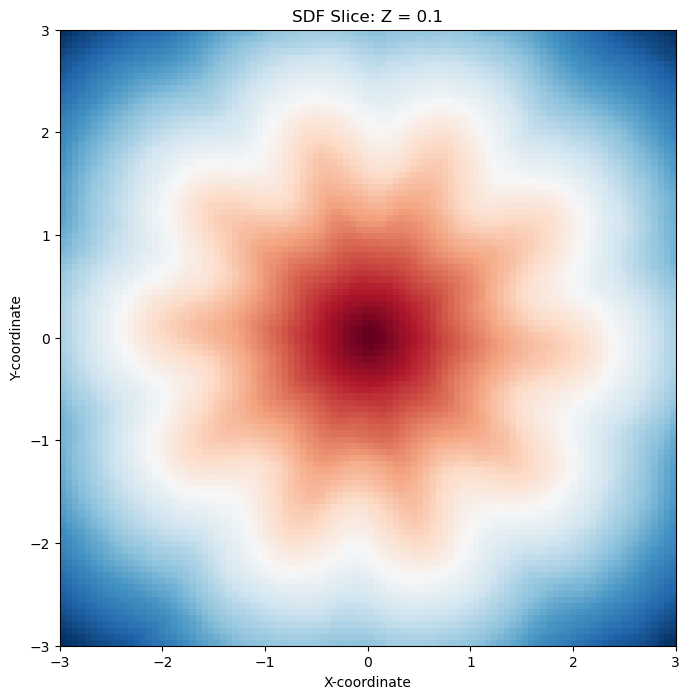

Generating 100x100 slice through Z=0.2...


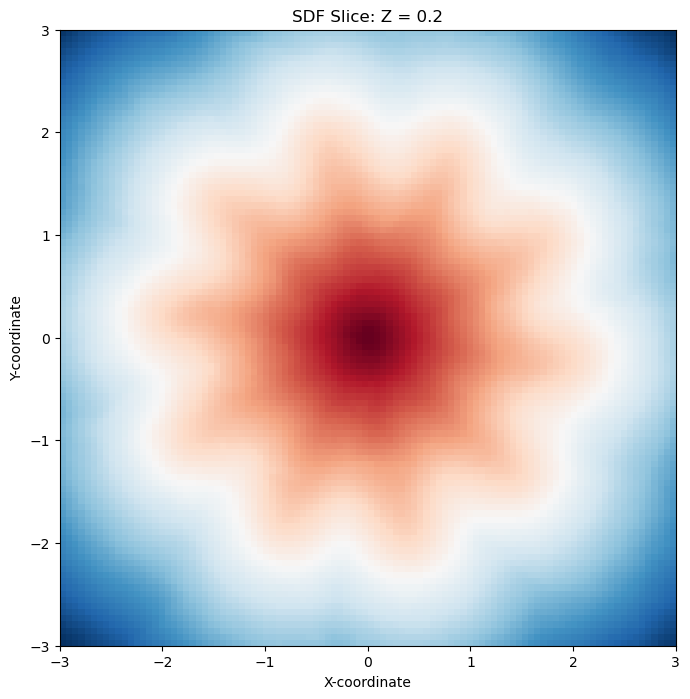

Generating 100x100 slice through Z=0.30000000000000004...


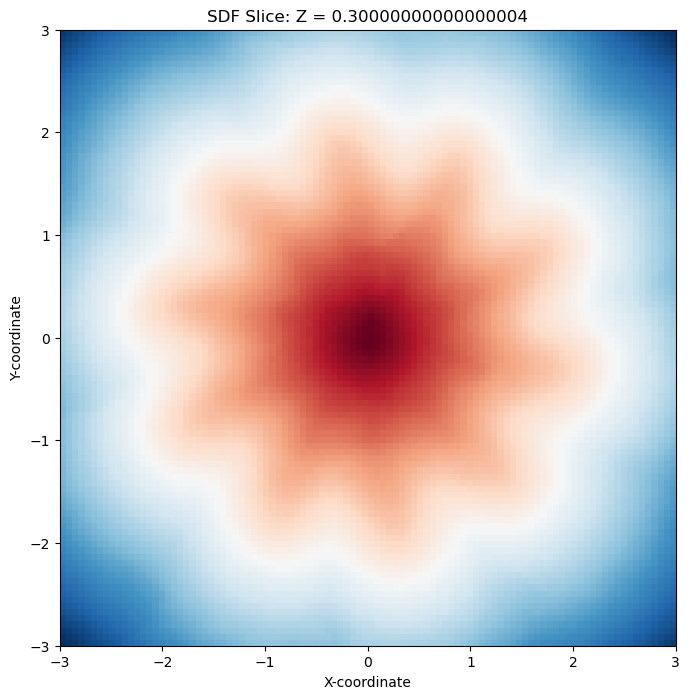

Generating 100x100 slice through Z=0.4...


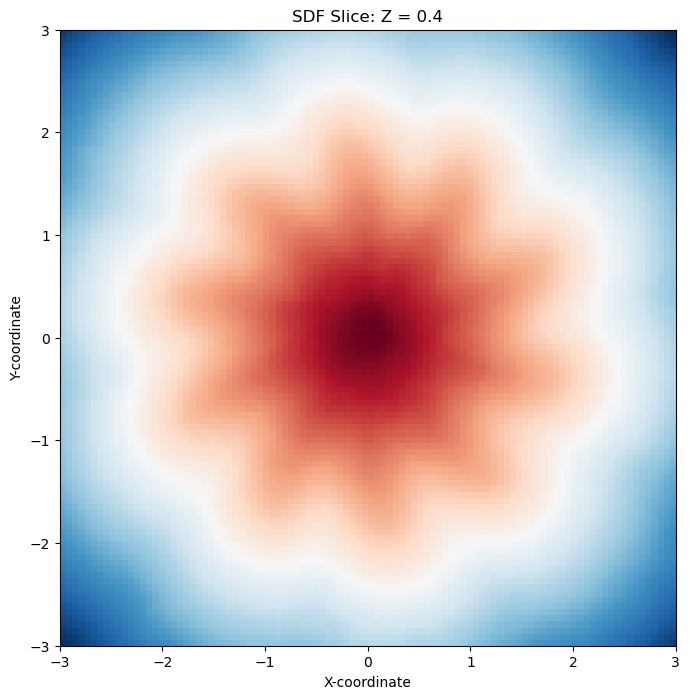

Generating 100x100 slice through Z=0.5...


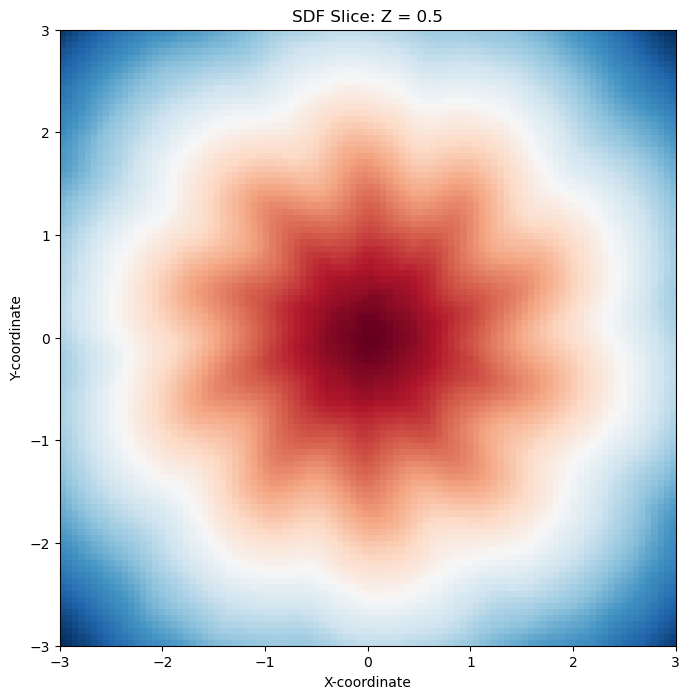

Generating 100x100 slice through Z=0.6000000000000001...


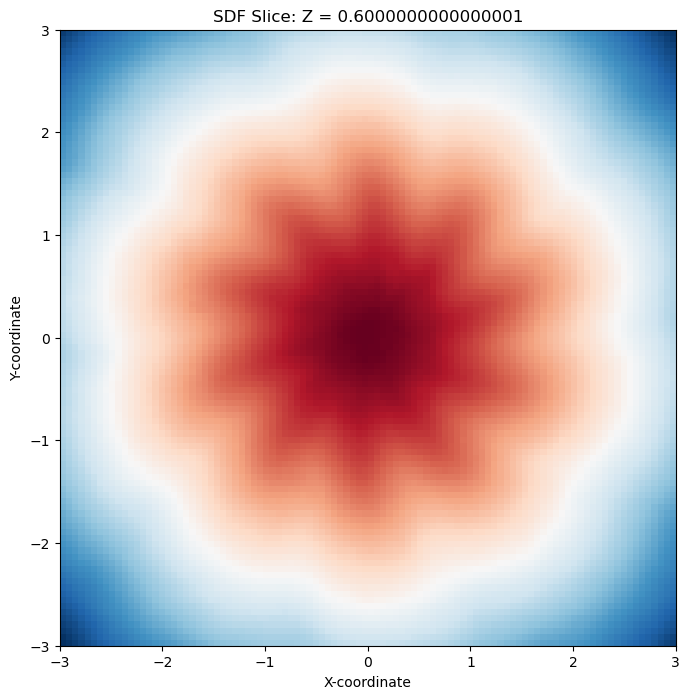

Generating 100x100 slice through Z=0.7000000000000001...


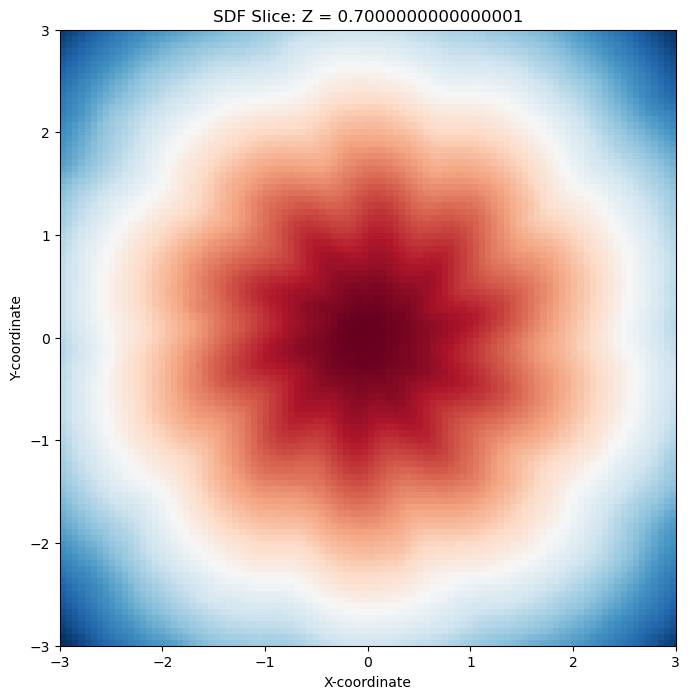

Generating 100x100 slice through Z=0.8...


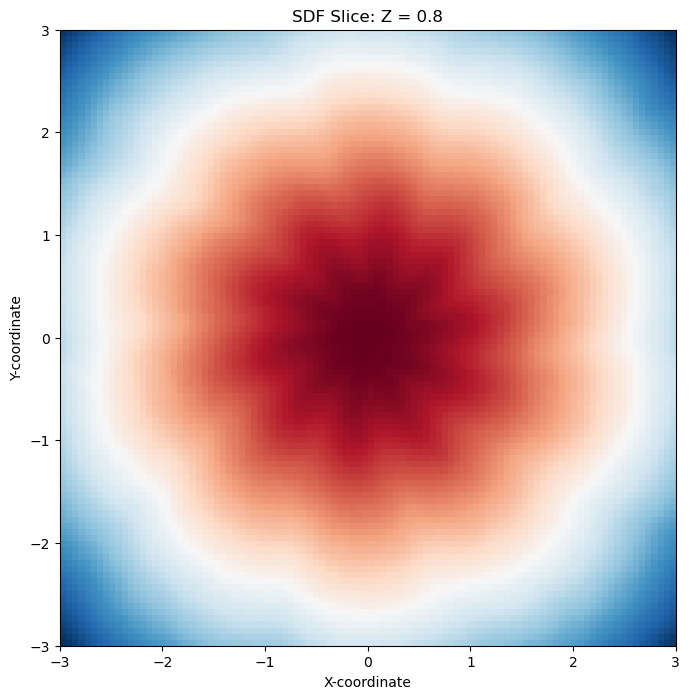

Generating 100x100 slice through Z=0.9...


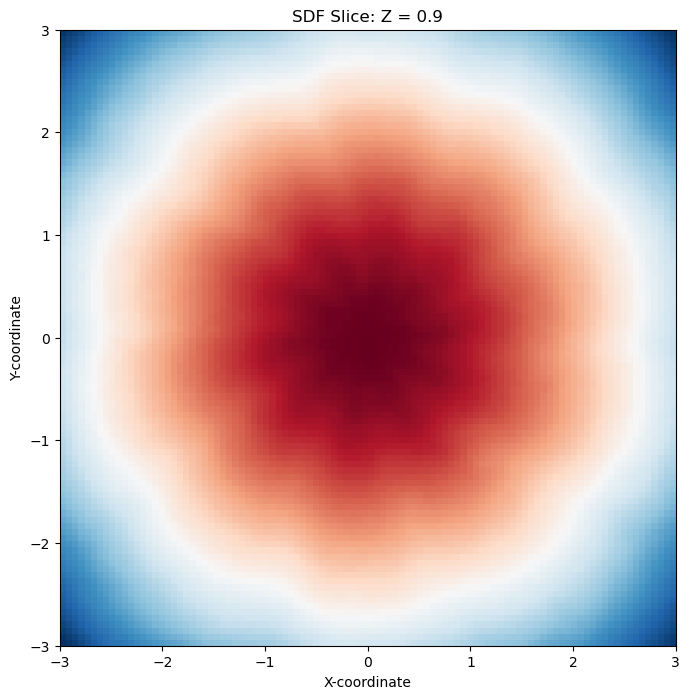

Generating 100x100 slice through Z=1.0...


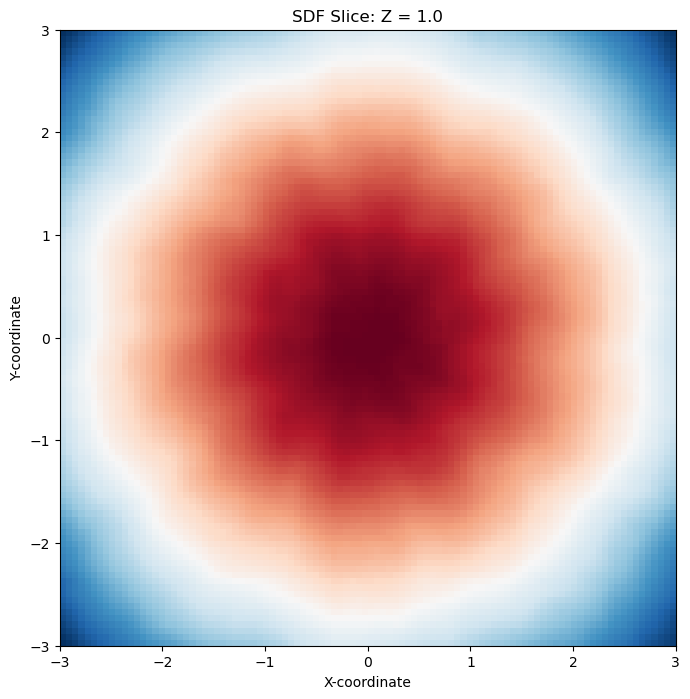

Generating 100x100 slice through Z=1.1...


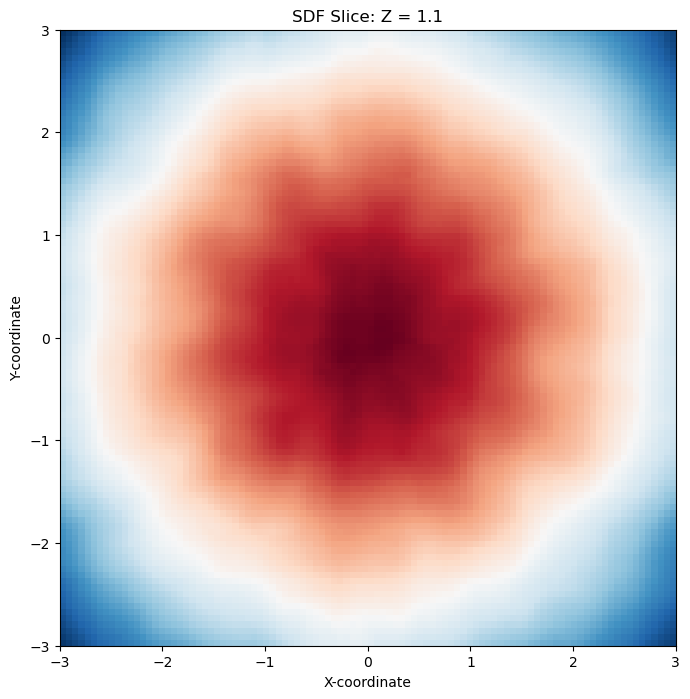

Generating 100x100 slice through Z=1.2000000000000002...


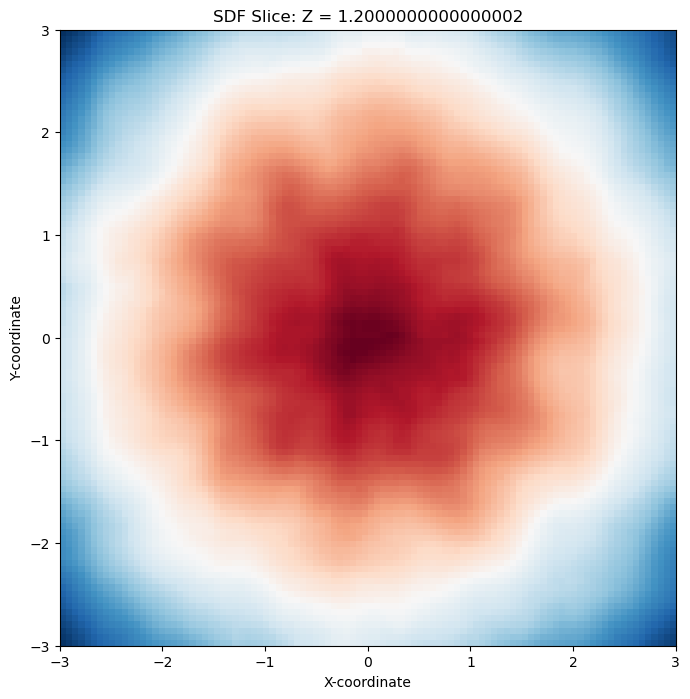

Generating 100x100 slice through Z=1.3...


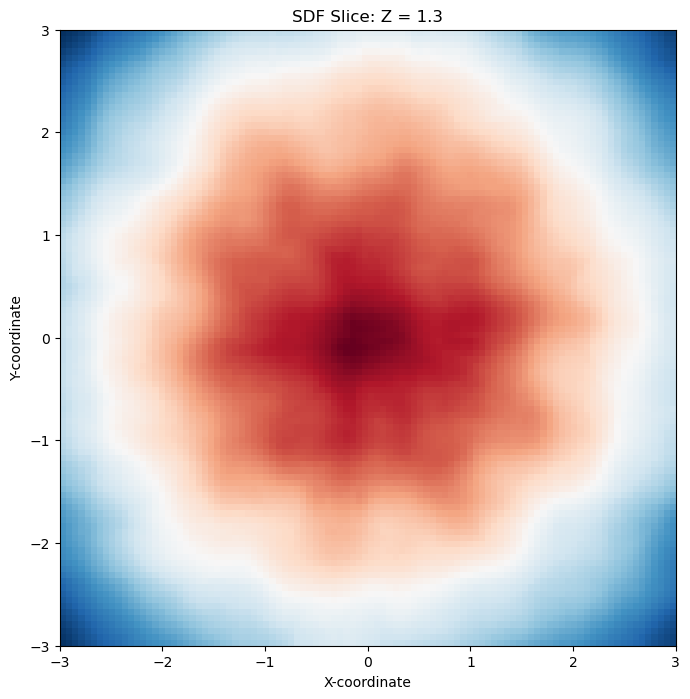

Generating 100x100 slice through Z=1.4000000000000001...


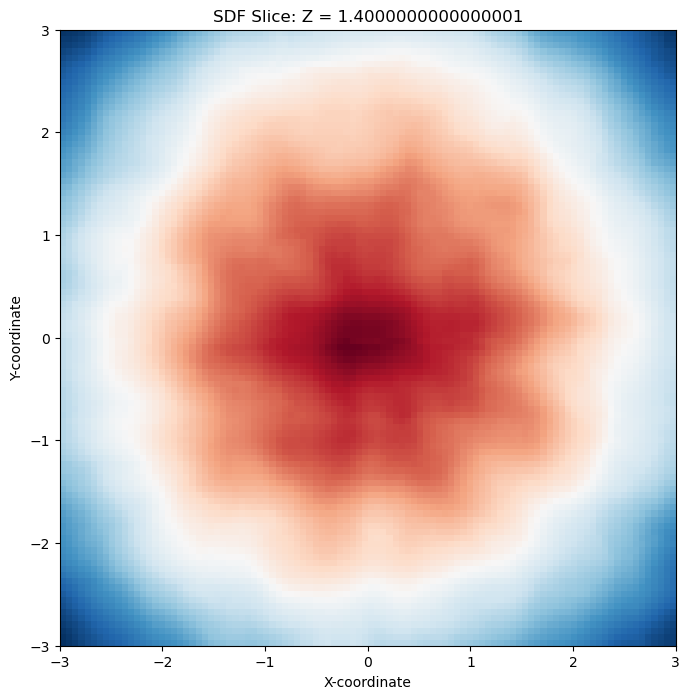

Generating 100x100 slice through Z=1.5...


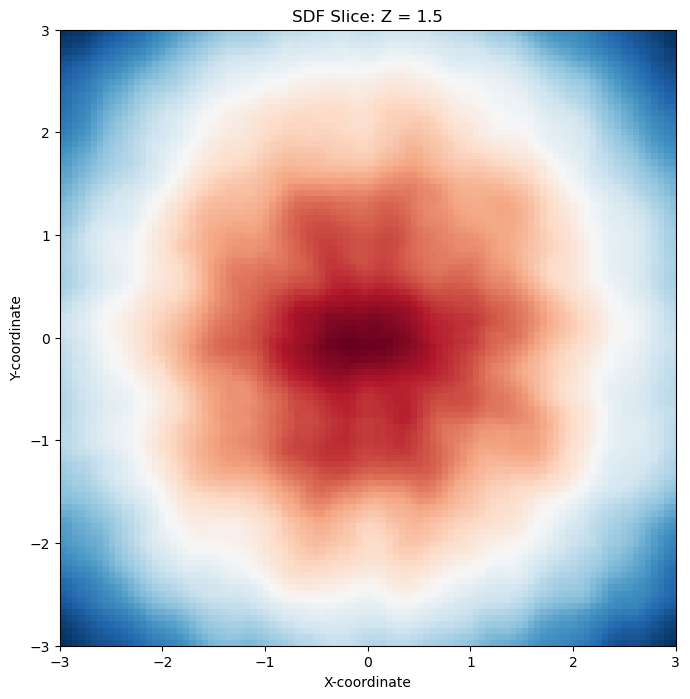

Generating 100x100 slice through Z=1.6...


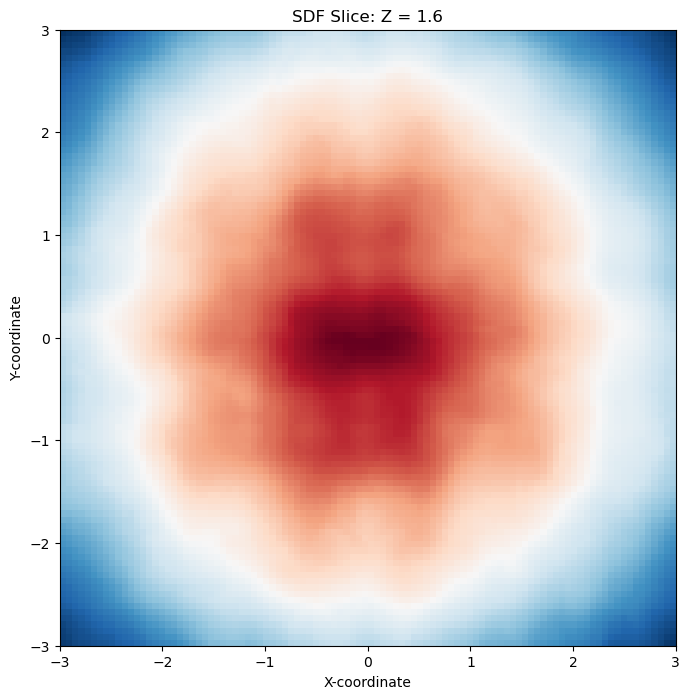

Generating 100x100 slice through Z=1.7000000000000002...


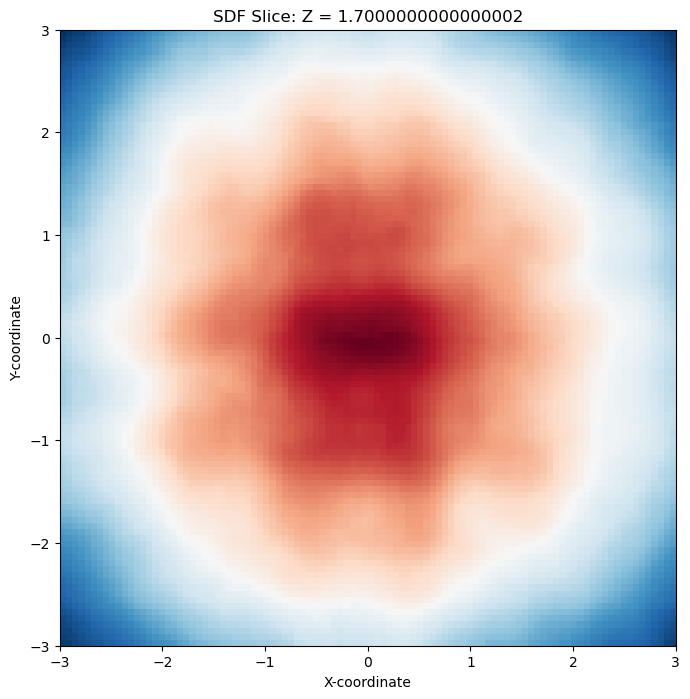

Generating 100x100 slice through Z=1.8...


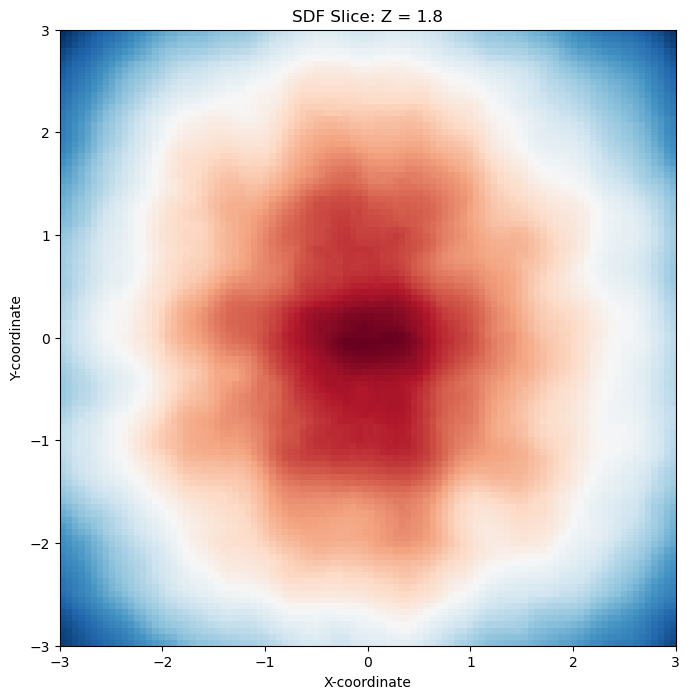

Generating 100x100 slice through Z=1.9000000000000001...


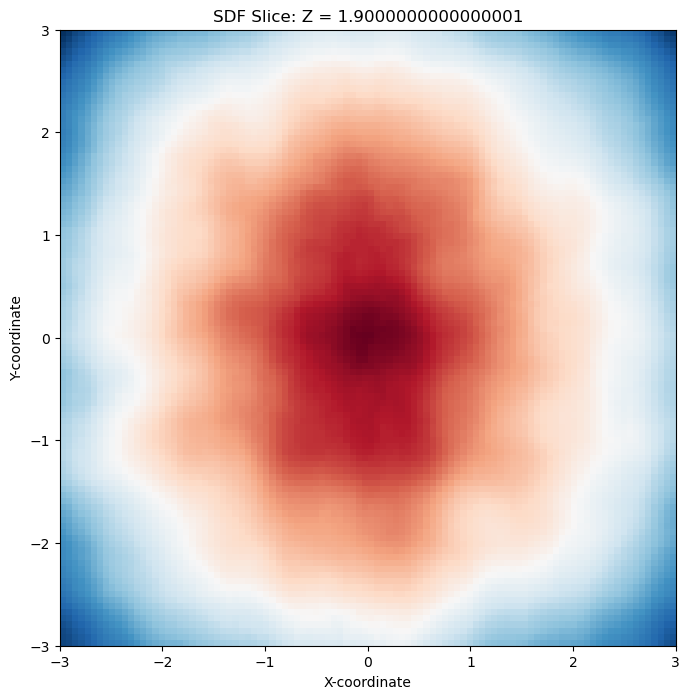

Generating 100x100 slice through Z=2.0...


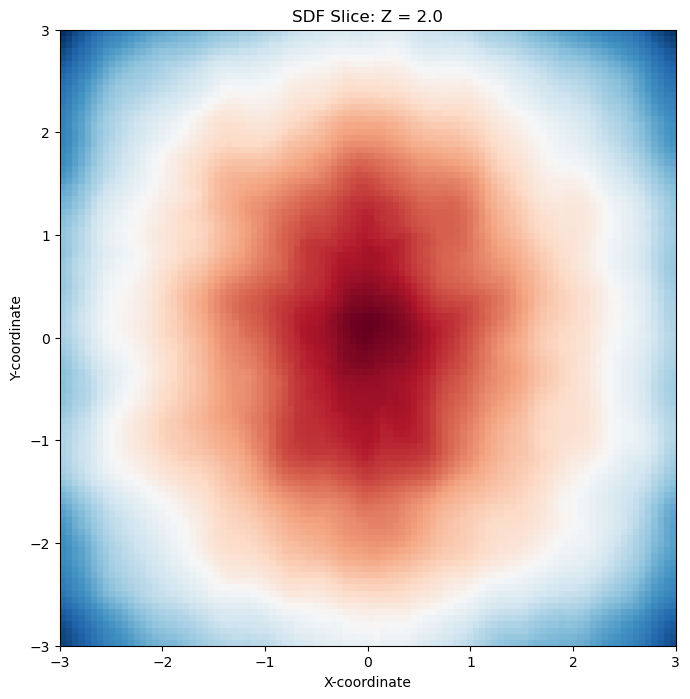

Generating 100x100 slice through Z=2.1...


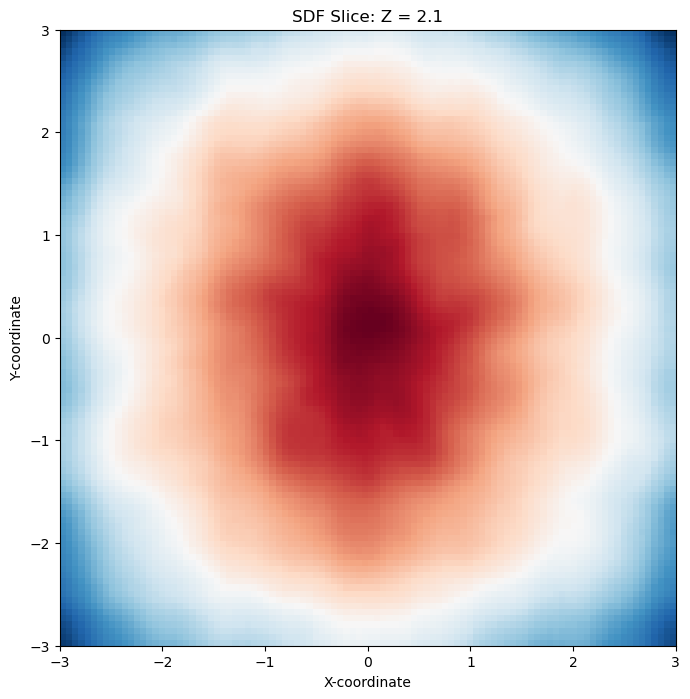

Generating 100x100 slice through Z=2.2...


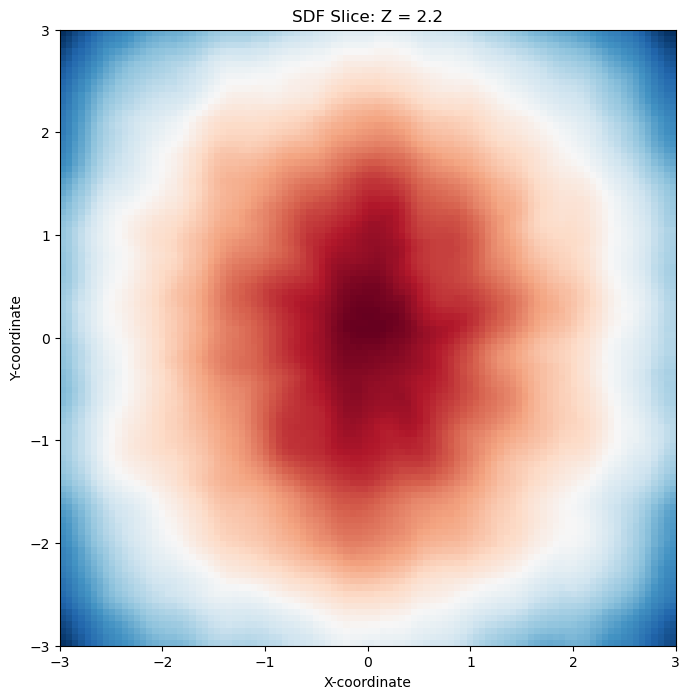

Generating 100x100 slice through Z=2.3000000000000003...


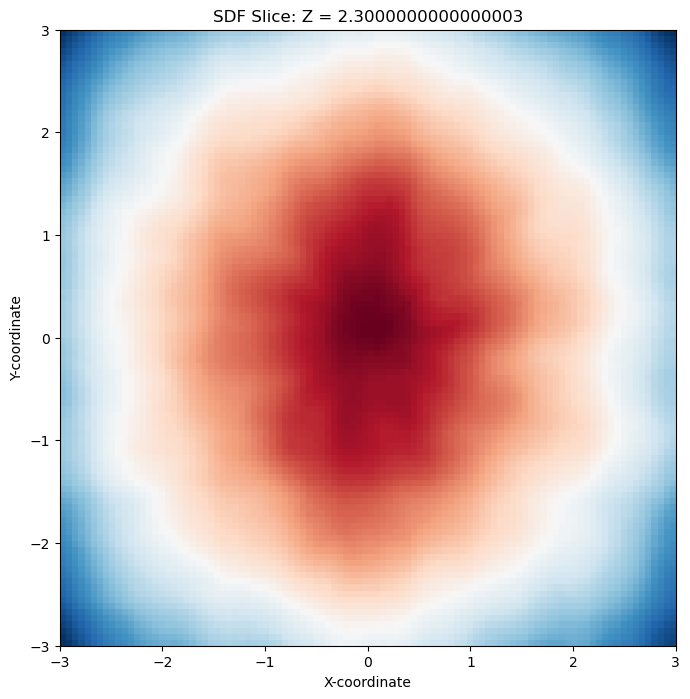

Generating 100x100 slice through Z=2.4000000000000004...


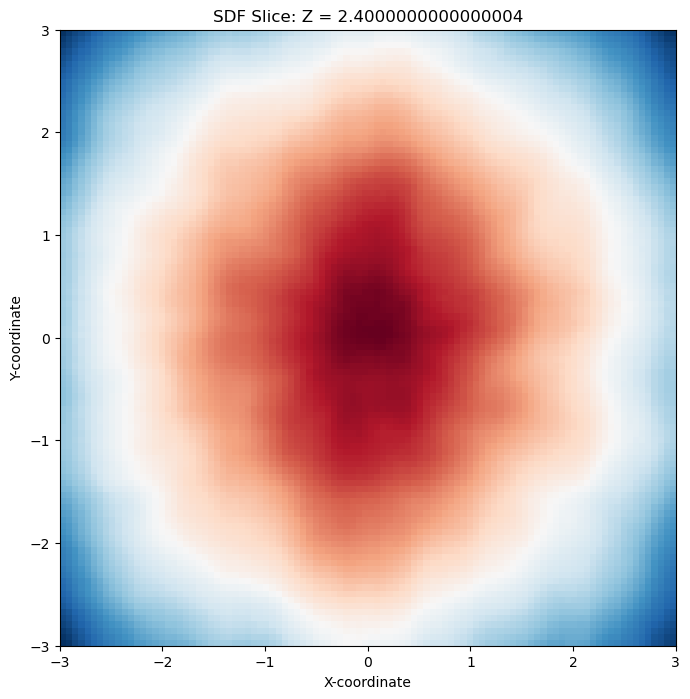

Generating 100x100 slice through Z=2.5...


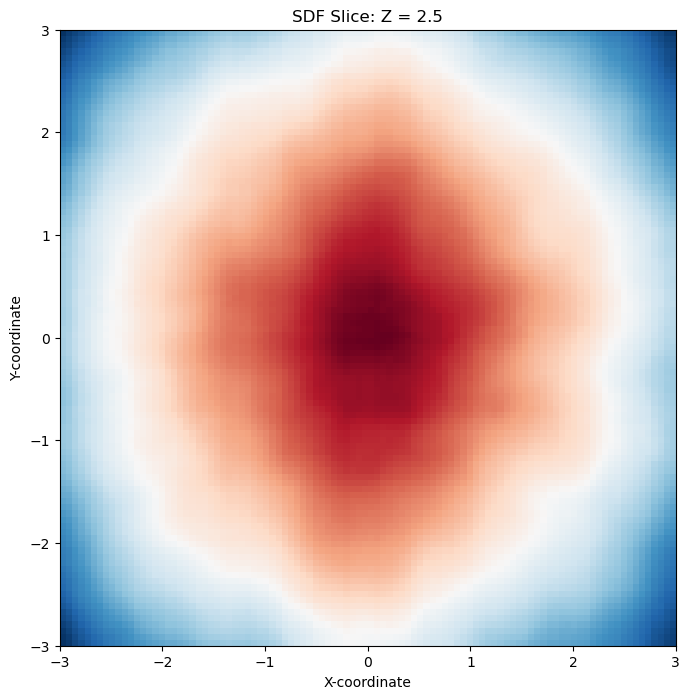

Generating 100x100 slice through Z=2.6...


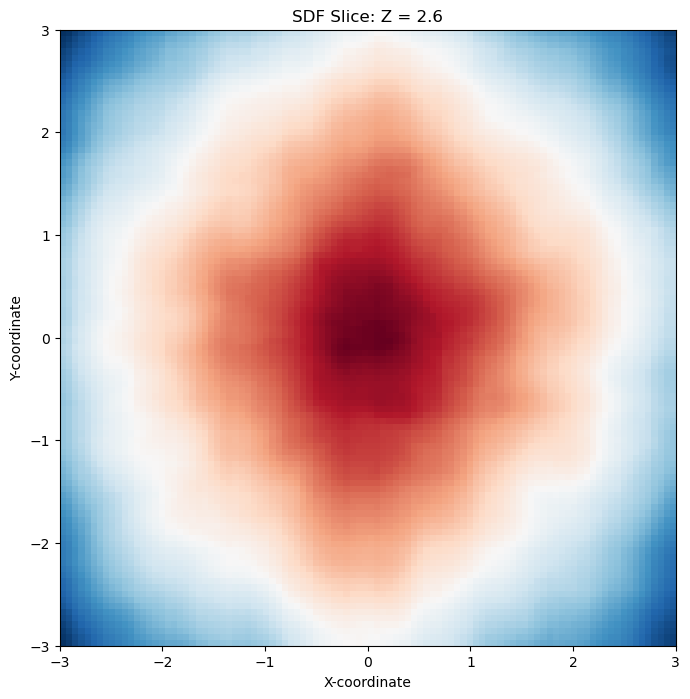

Generating 100x100 slice through Z=2.7...


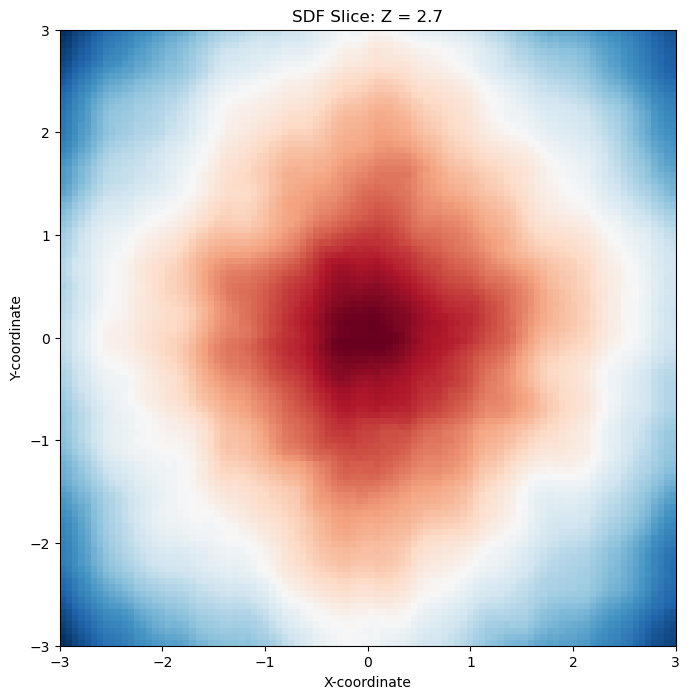

Generating 100x100 slice through Z=2.8000000000000003...


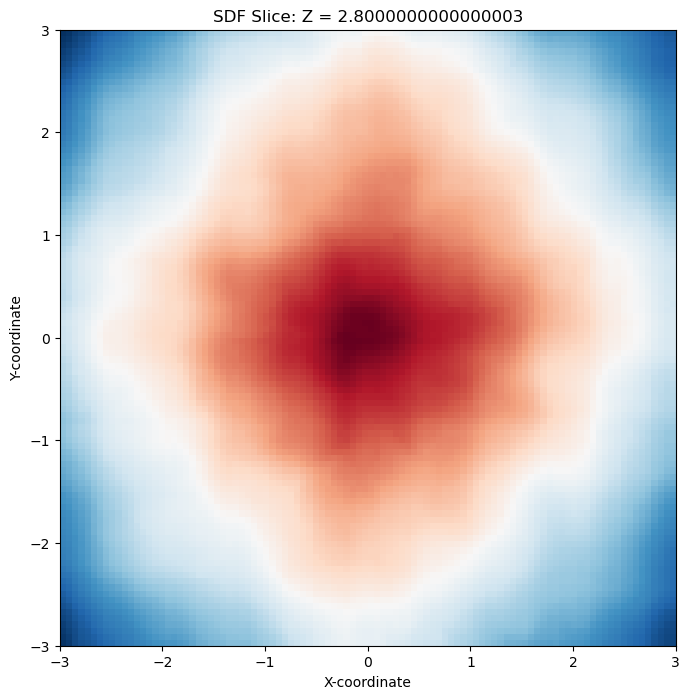

Generating 100x100 slice through Z=2.9000000000000004...


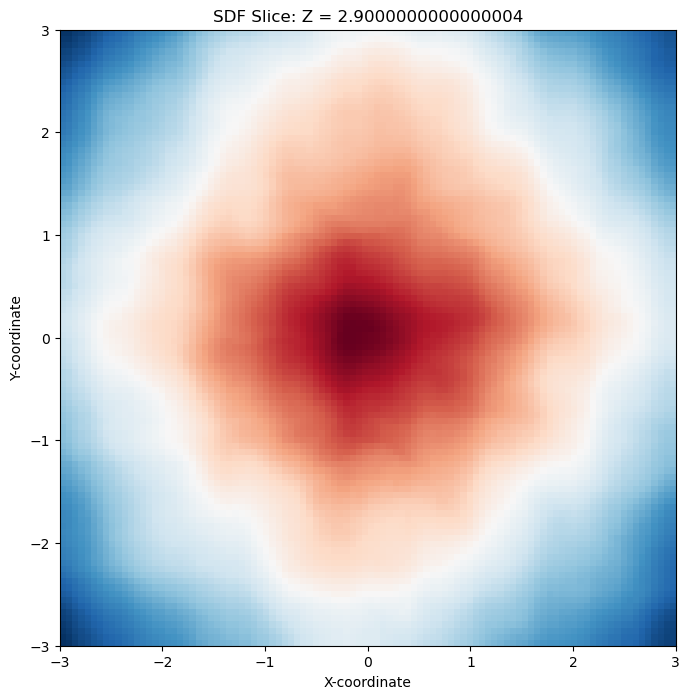

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_sdf_slice(model, device, resolution=500, slice_dim='Z', slice_val=0.1):
    """
    Generates and plots a 2D cross-section of the 3D SDF model.

    Args:
        model (nn.Module): The pre-loaded DEEPSDF_MODEL.
        device (torch.device): The device (e.g., 'mps', 'cuda').
        resolution (int): Number of points along each axis (e.g., 100x100 grid).
        slice_dim (str): The axis to slice along ('X', 'Y', or 'Z').
        slice_val (float): The coordinate value of the slice plane (e.g., 0.0).
    """
    print(f"Generating {resolution}x{resolution} slice through {slice_dim}={slice_val}...")
    
    # 1. Generate the 2D Grid (e.g., X and Y)
    grid_coords = torch.linspace(-1, 1, resolution, device=device)
    A, B = torch.meshgrid(grid_coords, grid_coords, indexing='ij')

    # 2. Map 2D Grid to 3D Query Points
    # Create the coordinate tensor (Resolution x Resolution x 3)
    if slice_dim == 'Z':
        # XY-Plane: (X, Y, Z=slice_val)
        C = torch.full_like(A, slice_val)
        query_points = torch.stack([A, B, C], dim=-1)
    elif slice_dim == 'Y':
        # XZ-Plane: (X, Y=slice_val, Z)
        C = torch.full_like(A, slice_val)
        query_points = torch.stack([A, C, B], dim=-1)
    elif slice_dim == 'X':
        # YZ-Plane: (X=slice_val, Y, Z)
        C = torch.full_like(A, slice_val)
        query_points = torch.stack([C, A, B], dim=-1)
    else:
        raise ValueError("slice_dim must be 'X', 'Y', or 'Z'.")

    # Reshape to (1, N*N, 3) for the model's batch input format
    query_points = query_points.reshape(1, -1, 3)
    
    # 3. Run DeepSDF Inference
    with torch.no_grad():
        # Ensure the model is on the correct device for the forward pass
        model.to(device)
        
        # The result has shape (1, N*N, 1). We only need the SDF value.
        sdf_result = deepsdf(query_points, model=model)
    
    # Synchronize to ensure computation is complete before moving data back
    if device == 'mps':
        torch.mps.synchronize() 
    elif device == 'cuda':
        torch.cuda.synchronize()

    # 4. Reshape and Prepare for Plotting
    # Move tensor to CPU and reshape to a 2D grid (Resolution x Resolution)
    sdf_values = sdf_result.squeeze().cpu().numpy().reshape(resolution, resolution)
    
    # 5. Plotting (Color Map/Heatmap)
    plt.figure(figsize=(8, 8))
    
    # Use imshow to create the color plot
    #mapped_sdf_values = sdf_values

    def mapping(x):
        return np.clip ( x*0.2 + 0.5, 0.0, 1.0)
        
    def inverse_mapping(y):
        return (y-0.5)*5
    
    im = plt.imshow(
        sdf_values,
        origin='lower',
        cmap='RdBu', # Red-Blue color map is standard for SDF
        extent=(-3, 3, -3, 3) 
    )
    
    # Plot the zero-level contour (the actual implicit surface)
    plt.contour(A.cpu().numpy(), B.cpu().numpy(), sdf_values, levels=[0.0], colors='black', linewidths=2)
    
    #plt.colorbar(inverse_mapping(sdf_values), label='Signed Distance Function (SDF) Value')
    
    # Set axis labels based on the slice
    if slice_dim == 'Z':
        plt.xlabel('X-coordinate')
        plt.ylabel('Y-coordinate')
        title = f'SDF Slice: Z = {slice_val}'
    elif slice_dim == 'Y':
        plt.xlabel('X-coordinate')
        plt.ylabel('Z-coordinate')
        title = f'SDF Slice: Y = {slice_val}'
    elif slice_dim == 'X':
        plt.xlabel('Y-coordinate')
        plt.ylabel('Z-coordinate')
        title = f'SDF Slice: X = {slice_val}'
        
    plt.title(title)
    plt.show()



for z_val in np.arange(0.0,3.0,0.1):
    plot_sdf_slice(DEEPSDF_MODEL, device, slice_val=z_val, resolution=100)